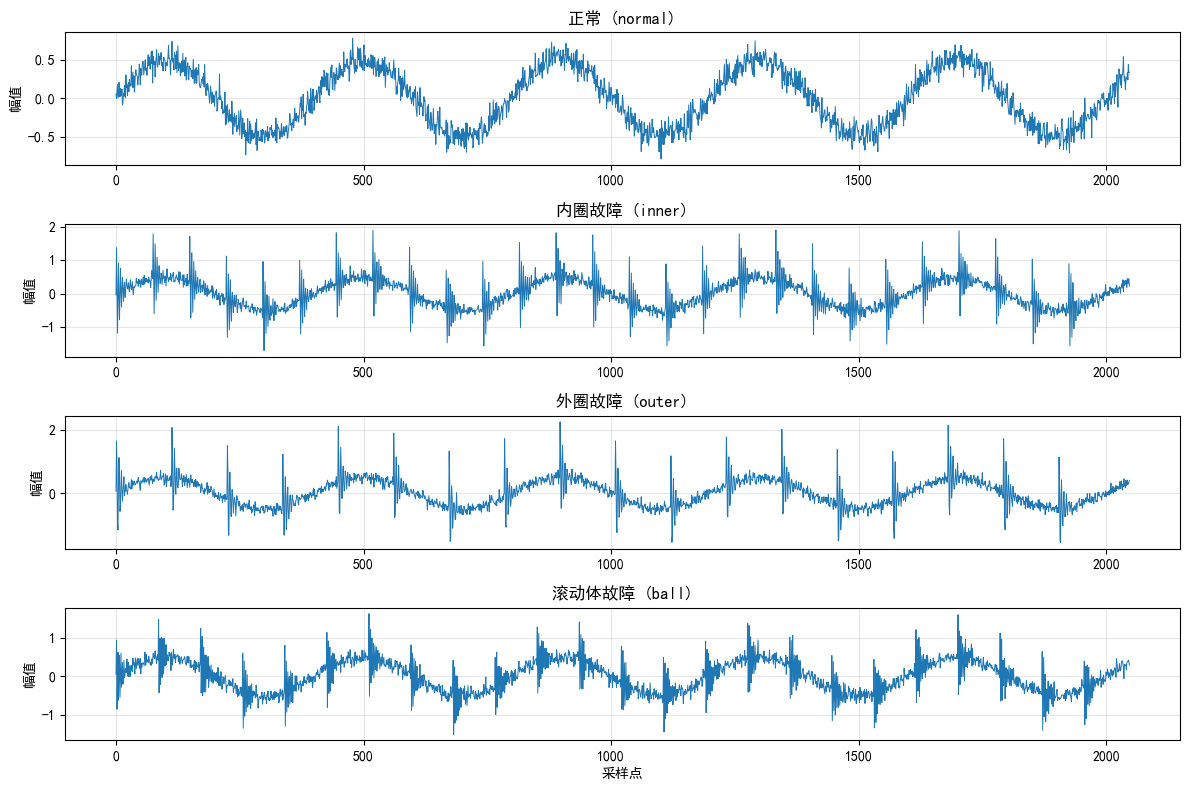


✅ 4类故障信号生成成功，已保存可视化图到 data/signal_visualization.png


In [1]:
"""
代码1：生成模拟轴承振动数据 + 可视化
项目：基于深度学习的轴承故障诊断系统
"""

import numpy as np
import matplotlib.pyplot as plt
import os

# 设置中文字体显示（Windows系统）
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 设置随机种子，保证结果可复现
np.random.seed(42)


def generate_bearing_signal(fault_type, n_samples=2048, fs=12000):
    """
    生成模拟轴承振动信号
    
    参数:
        fault_type: 故障类型 ('normal', 'inner', 'outer', 'ball')
        n_samples: 每个样本的点数（默认2048个采样点）
        fs: 采样频率（默认12kHz，模拟CWRU真实数据）
    
    返回:
        signal: 长度为n_samples的振动信号
    """
    # 时间轴
    t = np.arange(n_samples) / fs
    
    # 基础旋转频率（模拟电机转速30Hz）
    f_rotation = 30
    base_signal = 0.5 * np.sin(2 * np.pi * f_rotation * t)
    
    # 高斯噪声背景
    noise = 0.1 * np.random.randn(n_samples)
    
    if fault_type == 'normal':
        # 正常状态：基础旋转 + 噪声
        signal = base_signal + noise
        
    elif fault_type == 'inner':
        # 内圈故障：周期性冲击（频率约162Hz）
        f_fault = 162
        impulse = np.zeros(n_samples)
        impulse_period = int(fs / f_fault)
        for i in range(0, n_samples, impulse_period):
            if i + 50 < n_samples:
                # 衰减冲击响应
                decay = np.exp(-np.arange(50) / 10)
                impulse[i:i+50] += 1.5 * decay * np.sin(2*np.pi*3000*np.arange(50)/fs)
        signal = base_signal + impulse + noise
        
    elif fault_type == 'outer':
        # 外圈故障：周期性冲击（频率约107Hz，幅度更大）
        f_fault = 107
        impulse = np.zeros(n_samples)
        impulse_period = int(fs / f_fault)
        for i in range(0, n_samples, impulse_period):
            if i + 50 < n_samples:
                decay = np.exp(-np.arange(50) / 8)
                impulse[i:i+50] += 2.0 * decay * np.sin(2*np.pi*2500*np.arange(50)/fs)
        signal = base_signal + impulse + noise
        
    elif fault_type == 'ball':
        # 滚动体故障：双频冲击（141Hz）
        f_fault = 141
        impulse = np.zeros(n_samples)
        impulse_period = int(fs / f_fault)
        for i in range(0, n_samples, impulse_period):
            if i + 60 < n_samples:
                decay = np.exp(-np.arange(60) / 12)
                impulse[i:i+60] += 1.2 * decay * np.sin(2*np.pi*4000*np.arange(60)/fs)
        signal = base_signal + impulse + noise
    else:
        raise ValueError(f"未知的故障类型: {fault_type}")
    
    return signal


# === 生成4类信号样本，可视化 ===
fault_types = ['normal', 'inner', 'outer', 'ball']
labels_cn = ['正常', '内圈故障', '外圈故障', '滚动体故障']

fig, axes = plt.subplots(4, 1, figsize=(12, 8))
for i, (fault, label) in enumerate(zip(fault_types, labels_cn)):
    signal = generate_bearing_signal(fault)
    axes[i].plot(signal, linewidth=0.7)
    axes[i].set_title(f'{label} ({fault})', fontsize=12)
    axes[i].set_ylabel('幅值')
    axes[i].grid(True, alpha=0.3)
axes[-1].set_xlabel('采样点')
plt.tight_layout()
plt.savefig('../data/signal_visualization.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n✅ 4类故障信号生成成功，已保存可视化图到 data/signal_visualization.png")

In [2]:
"""
代码2：批量生成训练数据 + 划分训练集/测试集
说明：每个故障类别生成200个样本，共800个样本（4类 × 200）
"""

import numpy as np
from sklearn.model_selection import train_test_split

# 配置
N_SAMPLES_PER_CLASS = 200   # 每类生成200个样本
SIGNAL_LENGTH = 2048         # 每个样本2048个采样点
FAULT_TYPES = ['normal', 'inner', 'outer', 'ball']

print("正在生成数据集...\n")

# 批量生成数据
X_list = []
y_list = []

for label_idx, fault in enumerate(FAULT_TYPES):
    for _ in range(N_SAMPLES_PER_CLASS):
        signal = generate_bearing_signal(fault, n_samples=SIGNAL_LENGTH)
        X_list.append(signal)
        y_list.append(label_idx)
    print(f"  ✓ 生成 {fault:8s} (label={label_idx}): {N_SAMPLES_PER_CLASS} 个样本")

# 转为numpy数组
X = np.array(X_list)   # shape: (800, 2048)
y = np.array(y_list)   # shape: (800,)

print(f"\n📊 数据集总览:")
print(f"   X.shape = {X.shape}")
print(f"   y.shape = {y.shape}")
print(f"   类别分布: {np.bincount(y)}")

# 划分训练集/测试集（8:2）
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,        # 20%作为测试集
    random_state=42,
    stratify=y            # 保持类别比例平衡
)

print(f"\n✂️ 数据划分:")
print(f"   训练集: X_train={X_train.shape}, y_train={y_train.shape}")
print(f"   测试集: X_test={X_test.shape}, y_test={y_test.shape}")

# 数据归一化（每个样本独立做Z-score标准化）
def normalize(X):
    """每个样本独立进行Z-score归一化"""
    mean = X.mean(axis=1, keepdims=True)
    std = X.std(axis=1, keepdims=True) + 1e-8
    return (X - mean) / std

X_train_norm = normalize(X_train)
X_test_norm = normalize(X_test)

print(f"\n📐 归一化后数据范围:")
print(f"   X_train: [{X_train_norm.min():.2f}, {X_train_norm.max():.2f}]")
print(f"   X_test:  [{X_test_norm.min():.2f}, {X_test_norm.max():.2f}]")

# 保存数据，下次直接加载
np.savez('../data/bearing_dataset.npz',
         X_train=X_train_norm, y_train=y_train,
         X_test=X_test_norm, y_test=y_test)

print(f"\n✅ 数据已保存到 ../data/bearing_dataset.npz")
print(f"   下次加载: data = np.load('../data/bearing_dataset.npz')")

正在生成数据集...

  ✓ 生成 normal   (label=0): 200 个样本
  ✓ 生成 inner    (label=1): 200 个样本
  ✓ 生成 outer    (label=2): 200 个样本
  ✓ 生成 ball     (label=3): 200 个样本

📊 数据集总览:
   X.shape = (800, 2048)
   y.shape = (800,)
   类别分布: [200 200 200 200]

✂️ 数据划分:
   训练集: X_train=(640, 2048), y_train=(640,)
   测试集: X_test=(160, 2048), y_test=(160,)

📐 归一化后数据范围:
   X_train: [-4.38, 5.44]
   X_test:  [-4.02, 5.50]

✅ 数据已保存到 ../data/bearing_dataset.npz
   下次加载: data = np.load('../data/bearing_dataset.npz')


📊 正在提取统计特征...
   训练集特征维度: (640, 12)
   测试集特征维度: (160, 12)

🤖 训练 SVM 模型...
   ✅ SVM 准确率: 100.00%  (耗时 0.01s)

🌲 训练 随机森林模型...
   ✅ 随机森林 准确率: 100.00%  (耗时 0.16s)

📋 SVM 详细分类报告:
              precision    recall  f1-score   support

          正常       1.00      1.00      1.00        40
        内圈故障       1.00      1.00      1.00        40
        外圈故障       1.00      1.00      1.00        40
       滚动体故障       1.00      1.00      1.00        40

    accuracy                           1.00       160
   macro avg       1.00      1.00      1.00       160
weighted avg       1.00      1.00      1.00       160


📋 随机森林 详细分类报告:
              precision    recall  f1-score   support

          正常       1.00      1.00      1.00        40
        内圈故障       1.00      1.00      1.00        40
        外圈故障       1.00      1.00      1.00        40
       滚动体故障       1.00      1.00      1.00        40

    accuracy                           1.00       160
   macro avg       1.00      1.00      1.00      

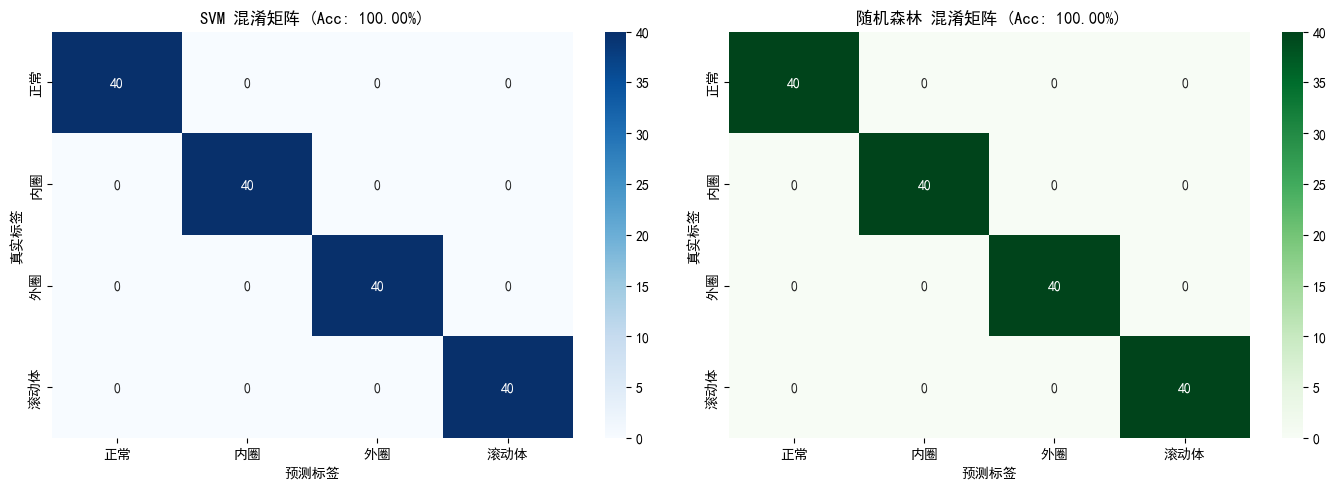

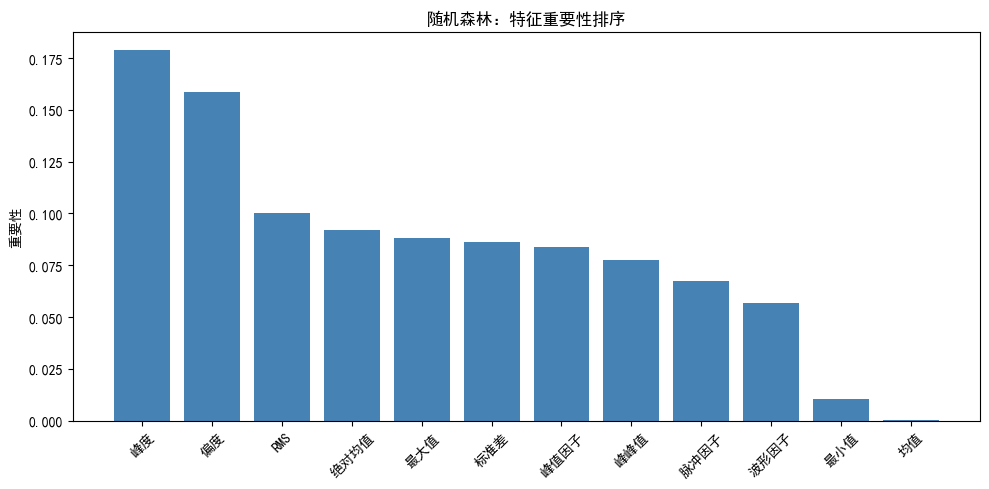


🏆 Baseline 模型对比
              accuracy   time
SVM             100.0%  0.01s
Random Forest   100.0%  0.16s

✅ Baseline完成！下一步用1D-CNN挑战更高准确率


In [3]:
"""
代码3：传统机器学习baseline
方法：从振动信号中提取统计特征 + SVM/随机森林分类
目的：作为深度学习模型的对比基线
"""

import numpy as np
import pandas as pd
from scipy import stats
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import time


def extract_features(signal):
    """
    从振动信号中提取12个常用统计特征
    
    参数:
        signal: 1D振动信号数组
    
    返回:
        features: 12维特征向量
    """
    features = [
        np.mean(signal),                    # 均值
        np.std(signal),                     # 标准差
        np.max(signal),                     # 最大值
        np.min(signal),                     # 最小值
        np.max(signal) - np.min(signal),    # 峰峰值
        np.sqrt(np.mean(signal**2)),        # 均方根 RMS
        np.mean(np.abs(signal)),            # 绝对均值
        stats.skew(signal),                 # 偏度
        stats.kurtosis(signal),             # 峰度
        np.max(np.abs(signal)) / np.sqrt(np.mean(signal**2)),  # 峰值因子
        np.sqrt(np.mean(signal**2)) / np.mean(np.abs(signal)), # 波形因子
        np.max(np.abs(signal)) / np.mean(np.abs(signal)),      # 脉冲因子
    ]
    return np.array(features)


# === 提取特征 ===
print("📊 正在提取统计特征...")
X_train_feat = np.array([extract_features(x) for x in X_train_norm])
X_test_feat = np.array([extract_features(x) for x in X_test_norm])

print(f"   训练集特征维度: {X_train_feat.shape}")
print(f"   测试集特征维度: {X_test_feat.shape}")

# 特征再次标准化（不同特征量级不同）
scaler = StandardScaler()
X_train_feat_scaled = scaler.fit_transform(X_train_feat)
X_test_feat_scaled = scaler.transform(X_test_feat)

# 特征名称（用于可视化）
feature_names = ['均值', '标准差', '最大值', '最小值', '峰峰值', 'RMS',
                 '绝对均值', '偏度', '峰度', '峰值因子', '波形因子', '脉冲因子']

# === 训练 SVM ===
print("\n🤖 训练 SVM 模型...")
start = time.time()
svm = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)
svm.fit(X_train_feat_scaled, y_train)
svm_pred = svm.predict(X_test_feat_scaled)
svm_acc = accuracy_score(y_test, svm_pred)
svm_time = time.time() - start
print(f"   ✅ SVM 准确率: {svm_acc*100:.2f}%  (耗时 {svm_time:.2f}s)")

# === 训练 随机森林 ===
print("\n🌲 训练 随机森林模型...")
start = time.time()
rf = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf.fit(X_train_feat_scaled, y_train)
rf_pred = rf.predict(X_test_feat_scaled)
rf_acc = accuracy_score(y_test, rf_pred)
rf_time = time.time() - start
print(f"   ✅ 随机森林 准确率: {rf_acc*100:.2f}%  (耗时 {rf_time:.2f}s)")

# === 详细分类报告 ===
print("\n" + "="*60)
print("📋 SVM 详细分类报告:")
print("="*60)
print(classification_report(y_test, svm_pred, 
                           target_names=['正常', '内圈故障', '外圈故障', '滚动体故障']))

print("\n" + "="*60)
print("📋 随机森林 详细分类报告:")
print("="*60)
print(classification_report(y_test, rf_pred,
                           target_names=['正常', '内圈故障', '外圈故障', '滚动体故障']))

# === 混淆矩阵可视化 ===
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_svm = confusion_matrix(y_test, svm_pred)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['正常', '内圈', '外圈', '滚动体'],
            yticklabels=['正常', '内圈', '外圈', '滚动体'],
            ax=axes[0])
axes[0].set_title(f'SVM 混淆矩阵 (Acc: {svm_acc*100:.2f}%)')
axes[0].set_xlabel('预测标签')
axes[0].set_ylabel('真实标签')

cm_rf = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['正常', '内圈', '外圈', '滚动体'],
            yticklabels=['正常', '内圈', '外圈', '滚动体'],
            ax=axes[1])
axes[1].set_title(f'随机森林 混淆矩阵 (Acc: {rf_acc*100:.2f}%)')
axes[1].set_xlabel('预测标签')
axes[1].set_ylabel('真实标签')

plt.tight_layout()
plt.savefig('../data/baseline_confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()

# === 特征重要性（来自随机森林）===
plt.figure(figsize=(10, 5))
importance = rf.feature_importances_
sorted_idx = np.argsort(importance)[::-1]
plt.bar(range(len(importance)), importance[sorted_idx], color='steelblue')
plt.xticks(range(len(importance)), [feature_names[i] for i in sorted_idx], rotation=45)
plt.ylabel('重要性')
plt.title('随机森林：特征重要性排序')
plt.tight_layout()
plt.savefig('../data/feature_importance.png', dpi=100, bbox_inches='tight')
plt.show()

# === 保存baseline结果 ===
baseline_results = {
    'SVM': {'accuracy': svm_acc, 'time': svm_time},
    'Random Forest': {'accuracy': rf_acc, 'time': rf_time}
}

print("\n" + "="*60)
print("🏆 Baseline 模型对比")
print("="*60)
results_df = pd.DataFrame(baseline_results).T
results_df['accuracy'] = (results_df['accuracy'] * 100).round(2).astype(str) + '%'
results_df['time'] = results_df['time'].round(2).astype(str) + 's'
print(results_df)
print("\n✅ Baseline完成！下一步用1D-CNN挑战更高准确率")

TensorFlow 版本: 2.21.0
GPU 可用: False

📐 CNN输入形状:
   X_train_cnn: (640, 2048, 1)
   y_train_onehot: (640, 4)

🏗️ 构建 1D-CNN 模型...

📊 模型结构:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 256, 32)        │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 128, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 128, 64)        │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 64, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 64, 128)        │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 32, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,988 (429.64 KB)

 Trainable params: 109,540 (427.89 KB)

 Non-trainable params: 448 (1.75 KB)


🚀 开始训练...
Epoch 1/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - accuracy: 0.9316 - loss: 0.2710 - val_accuracy: 0.6562 - val_loss: 1.1875 - learning_rate: 0.0010
Epoch 2/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 1.0000 - loss: 0.0136 - val_accuracy: 0.7656 - val_loss: 0.9927 - learning_rate: 0.0010
Epoch 3/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 1.0000 - loss: 0.0105 - val_accuracy: 0.3203 - val_loss: 1.1218 - learning_rate: 0.0010
Epoch 4/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 1.0000 - loss: 0.0045 - val_accuracy: 0.3203 - val_loss: 1.5395 - learning_rate: 0.0010
Epoch 5/30
15/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9999 - loss: 0.0062
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9980 - loss: 0.0074 - val_accuracy: 0.3203 - val_loss: 2.0932 - learning_rate: 0.0010
Epoch 6/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 1.0000 - loss: 0.0043

C:\Users\28725\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\28725\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\28725\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

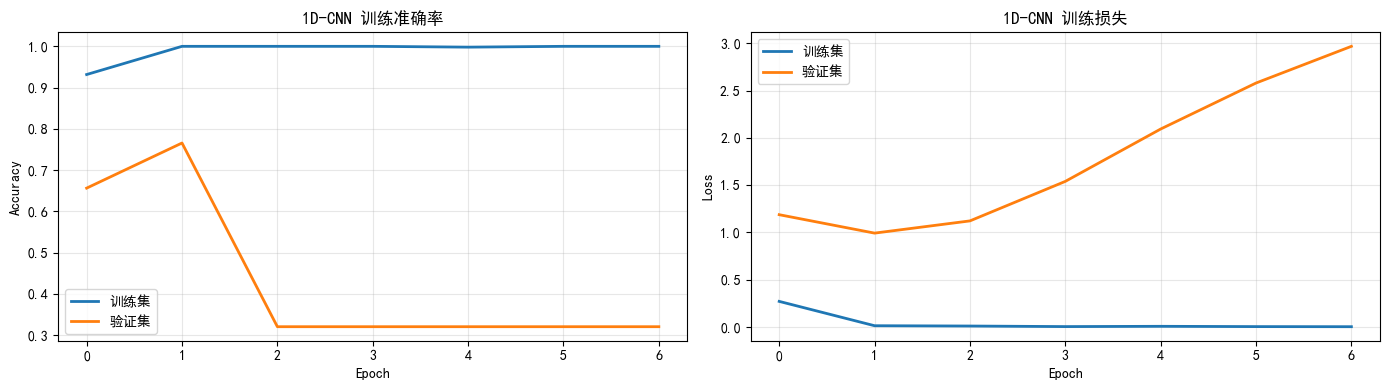

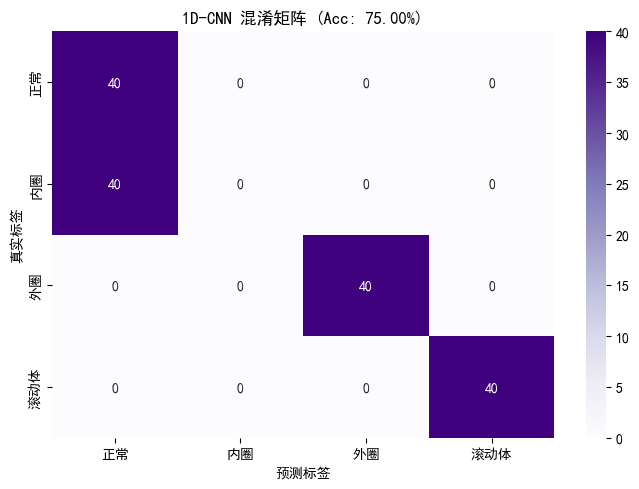


✅ 模型已保存到 ../data/bearing_cnn_model.h5

🏆 1D-CNN 最终成绩:
   测试准确率: 75.00%
   训练耗时:   6.5s
   实际训练轮数: 7 epochs


In [4]:
"""
代码4：1D-CNN深度学习模型
原理：用一维卷积神经网络直接从振动信号中学习特征，端到端分类
优势：无需手工特征提取，自动学习更深层的故障模式
"""

import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import time

# 设置随机种子保证可复现
tf.random.set_seed(42)
np.random.seed(42)

print(f"TensorFlow 版本: {tf.__version__}")
print(f"GPU 可用: {len(tf.config.list_physical_devices('GPU')) > 0}\n")

# === 数据准备：转成CNN需要的形状 ===
# CNN输入需要3D: (样本数, 信号长度, 通道数)
X_train_cnn = X_train_norm.reshape(-1, 2048, 1)  # (640, 2048, 1)
X_test_cnn = X_test_norm.reshape(-1, 2048, 1)    # (160, 2048, 1)

# 标签转 one-hot 编码
y_train_onehot = to_categorical(y_train, num_classes=4)
y_test_onehot = to_categorical(y_test, num_classes=4)

print(f"📐 CNN输入形状:")
print(f"   X_train_cnn: {X_train_cnn.shape}")
print(f"   y_train_onehot: {y_train_onehot.shape}\n")


# === 构建1D-CNN模型 ===
def build_1d_cnn(input_length=2048, num_classes=4):
    """
    构建一维卷积神经网络
    架构: 3层卷积 + 池化 → 全连接 → 输出
    """
    model = models.Sequential([
        # 输入层
        layers.Input(shape=(input_length, 1)),
        
        # 第1个卷积块：捕获短期局部特征
        layers.Conv1D(filters=32, kernel_size=64, strides=8, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),
        
        # 第2个卷积块：捕获中期模式
        layers.Conv1D(filters=64, kernel_size=16, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),
        
        # 第3个卷积块：捕获深层抽象特征
        layers.Conv1D(filters=128, kernel_size=8, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),
        
        # 全局平均池化（替代Flatten，参数更少）
        layers.GlobalAveragePooling1D(),
        
        # 全连接层
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.5),  # 防止过拟合
        
        # 输出层（4分类）
        layers.Dense(num_classes, activation='softmax')
    ])
    
    return model


# === 创建模型 ===
print("🏗️ 构建 1D-CNN 模型...")
model = build_1d_cnn(input_length=2048, num_classes=4)

# 编译模型
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 显示模型结构
print("\n📊 模型结构:")
model.summary()


# === 训练模型 ===
print("\n🚀 开始训练...")
start = time.time()

# 早停策略：3轮内验证集准确率不提升就停止
early_stop = callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# 学习率衰减
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

history = model.fit(
    X_train_cnn, y_train_onehot,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

train_time = time.time() - start
print(f"\n⏱️ 训练耗时: {train_time:.1f}s")


# === 测试集评估 ===
print("\n🎯 测试集评估...")
test_loss, test_acc = model.evaluate(X_test_cnn, y_test_onehot, verbose=0)
print(f"   测试损失: {test_loss:.4f}")
print(f"   测试准确率: {test_acc*100:.2f}%")

# 详细分类报告
y_pred = np.argmax(model.predict(X_test_cnn, verbose=0), axis=1)
print("\n📋 1D-CNN 详细分类报告:")
print(classification_report(y_test, y_pred,
                           target_names=['正常', '内圈故障', '外圈故障', '滚动体故障']))


# === 可视化：训练曲线 ===
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# 准确率曲线
axes[0].plot(history.history['accuracy'], label='训练集', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='验证集', linewidth=2)
axes[0].set_title('1D-CNN 训练准确率')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 损失曲线
axes[1].plot(history.history['loss'], label='训练集', linewidth=2)
axes[1].plot(history.history['val_loss'], label='验证集', linewidth=2)
axes[1].set_title('1D-CNN 训练损失')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/cnn_training_curves.png', dpi=100, bbox_inches='tight')
plt.show()


# === 可视化：混淆矩阵 ===
plt.figure(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['正常', '内圈', '外圈', '滚动体'],
            yticklabels=['正常', '内圈', '外圈', '滚动体'])
plt.title(f'1D-CNN 混淆矩阵 (Acc: {test_acc*100:.2f}%)')
plt.xlabel('预测标签')
plt.ylabel('真实标签')
plt.tight_layout()
plt.savefig('../data/cnn_confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()


# === 保存模型 ===
model.save('../data/bearing_cnn_model.h5')
print(f"\n✅ 模型已保存到 ../data/bearing_cnn_model.h5")

# 保存CNN结果（便于后面对比）
cnn_result = {
    'accuracy': test_acc,
    'training_time': train_time,
    'epochs_trained': len(history.history['accuracy'])
}
print(f"\n🏆 1D-CNN 最终成绩:")
print(f"   测试准确率: {cnn_result['accuracy']*100:.2f}%")
print(f"   训练耗时:   {cnn_result['training_time']:.1f}s")
print(f"   实际训练轮数: {cnn_result['epochs_trained']} epochs")

🏗️ 构建优化版 1D-CNN...

📊 模型结构:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_3 (Conv1D)               │ (None, 512, 16)        │         2,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 512, 16)        │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 128, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 128, 32)        │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 32, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 32, 64)         │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 16, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,044 (363.45 KB)

 Trainable params: 92,820 (362.58 KB)

 Non-trainable params: 224 (896.00 B)


🚀 开始训练（这次要充分训练）...
Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.7441 - loss: 0.7620 - val_accuracy: 1.0000 - val_loss: 0.9704 - learning_rate: 0.0010
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9902 - loss: 0.0339 - val_accuracy: 0.5703 - val_loss: 0.7505 - learning_rate: 0.0010
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9980 - loss: 0.0067 - val_accuracy: 0.5703 - val_loss: 1.2828 - learning_rate: 0.0010
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9980 - loss: 0.0044 - val_accuracy: 0.3203 - val_loss: 2.1646 - learning_rate: 0.0010
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 1.0000 - loss: 0.0012 - val_accuracy: 0.3203 - val_loss: 3.0758 - learning_rate: 0.0010
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 1.0000 - loss: 0.0017 - val_accuracy: 0.3203 - val_loss: 3.7658 - learning_rate: 0.0010
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 1.0000 - lo

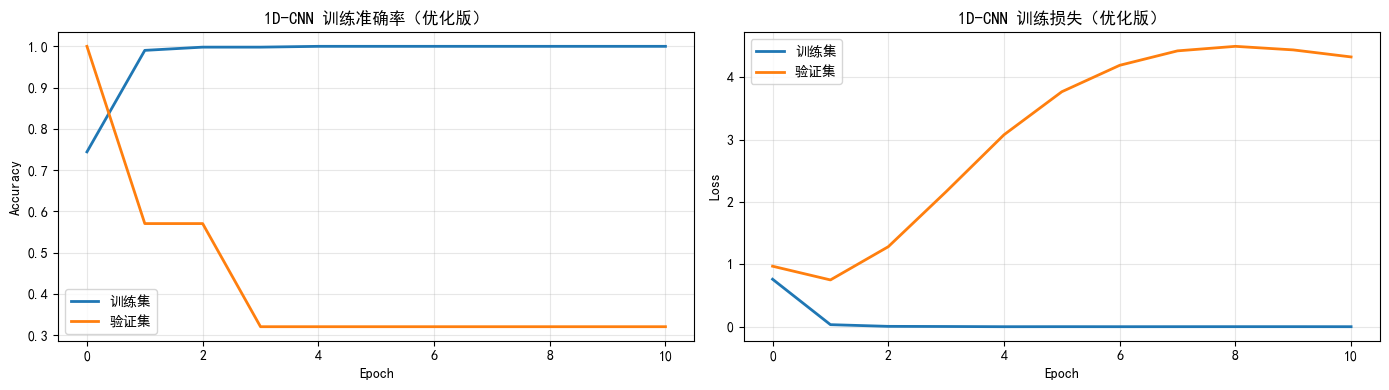

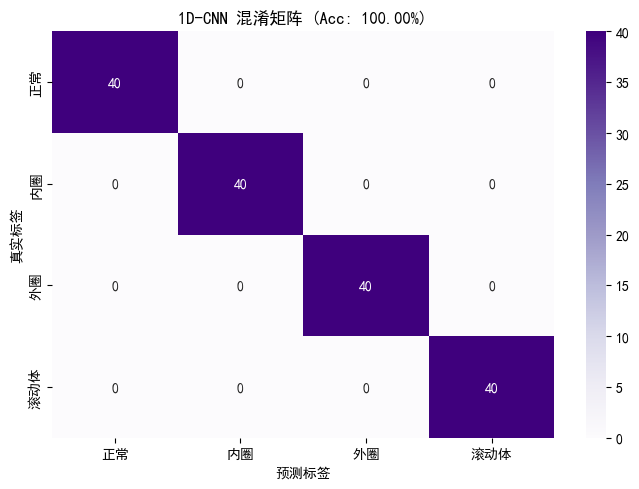


✅ 模型已保存到 ../data/bearing_cnn_model.keras

🏆 1D-CNN 最终成绩:
   测试准确率: 100.00%
   训练耗时:   5.3s
   实际训练轮数: 11 epochs


In [5]:
"""
代码4-修复版：优化的1D-CNN
改进：
1. 简化网络结构（数据量不大，避免过拟合）
2. 增加训练耐心，让模型充分学习
3. 优化学习率策略
"""

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

# 重置随机种子
tf.random.set_seed(123)
np.random.seed(123)


# === 重新构建模型（更适合小数据集）===
def build_better_cnn(input_length=2048, num_classes=4):
    """
    更精简的1D-CNN，适合中小规模轴承数据
    """
    model = models.Sequential([
        layers.Input(shape=(input_length, 1)),
        
        # 第1块：宽卷积核捕获信号特征
        layers.Conv1D(16, kernel_size=128, strides=4, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=4),
        layers.Dropout(0.2),
        
        # 第2块
        layers.Conv1D(32, kernel_size=16, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=4),
        layers.Dropout(0.2),
        
        # 第3块
        layers.Conv1D(64, kernel_size=8, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),
        layers.Dropout(0.2),
        
        # 分类头
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(num_classes, activation='softmax')
    ])
    
    return model


# 创建新模型
print("🏗️ 构建优化版 1D-CNN...")
model = build_better_cnn(input_length=2048, num_classes=4)

# 编译
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\n📊 模型结构:")
model.summary()


# === 训练（更耐心、更充分）===
print("\n🚀 开始训练（这次要充分训练）...")
start = time.time()

# 早停：增加patience到10，给模型更多机会
early_stop = callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=10,             # 从5增加到10
    restore_best_weights=True,
    verbose=1
)

# 学习率衰减：更晚触发
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=6,              # 从3增加到6
    min_lr=1e-6,
    verbose=1
)

history = model.fit(
    X_train_cnn, y_train_onehot,
    validation_split=0.2,
    epochs=50,               # 增加最大轮数
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

train_time = time.time() - start
print(f"\n⏱️ 训练耗时: {train_time:.1f}s")
print(f"⏱️ 实际训练: {len(history.history['accuracy'])} epochs")


# === 测试集评估 ===
test_loss, test_acc = model.evaluate(X_test_cnn, y_test_onehot, verbose=0)
print(f"\n🎯 测试准确率: {test_acc*100:.2f}%")

# 详细报告
y_pred = np.argmax(model.predict(X_test_cnn, verbose=0), axis=1)
print("\n📋 1D-CNN 详细分类报告:")
print(classification_report(y_test, y_pred,
                           target_names=['正常', '内圈故障', '外圈故障', '滚动体故障']))


# === 训练曲线 ===
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history.history['accuracy'], label='训练集', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='验证集', linewidth=2)
axes[0].set_title('1D-CNN 训练准确率（优化版）')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'], label='训练集', linewidth=2)
axes[1].plot(history.history['val_loss'], label='验证集', linewidth=2)
axes[1].set_title('1D-CNN 训练损失（优化版）')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/cnn_training_curves_v2.png', dpi=100, bbox_inches='tight')
plt.show()


# === 混淆矩阵 ===
plt.figure(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['正常', '内圈', '外圈', '滚动体'],
            yticklabels=['正常', '内圈', '外圈', '滚动体'])
plt.title(f'1D-CNN 混淆矩阵 (Acc: {test_acc*100:.2f}%)')
plt.xlabel('预测标签')
plt.ylabel('真实标签')
plt.tight_layout()
plt.savefig('../data/cnn_confusion_matrix_v2.png', dpi=100, bbox_inches='tight')
plt.show()


# 保存模型（用新格式避免警告）
model.save('../data/bearing_cnn_model.keras')
print(f"\n✅ 模型已保存到 ../data/bearing_cnn_model.keras")

# 保存CNN结果
cnn_result = {
    'accuracy': test_acc,
    'training_time': train_time,
    'epochs_trained': len(history.history['accuracy'])
}
print(f"\n🏆 1D-CNN 最终成绩:")
print(f"   测试准确率: {cnn_result['accuracy']*100:.2f}%")
print(f"   训练耗时:   {cnn_result['training_time']:.1f}s")
print(f"   实际训练轮数: {cnn_result['epochs_trained']} epochs")


📐 数据降采样（2048 → 256）...
   X_train_lstm: (640, 256, 1)
   X_test_lstm: (160, 256, 1)

🏗️ 构建 LSTM 模型...

📊 LSTM 模型结构:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 256, 64)        │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,500 (119.14 KB)

 Trainable params: 30,500 (119.14 KB)

 Non-trainable params: 0 (0.00 B)


🚀 开始训练（LSTM比CNN慢，请耐心等待）...
Epoch 1/40
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 102ms/step - accuracy: 0.2402 - loss: 1.3874 - val_accuracy: 0.3203 - val_loss: 1.3796 - learning_rate: 0.0010
Epoch 2/40
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - accuracy: 0.2578 - loss: 1.3862 - val_accuracy: 0.4141 - val_loss: 1.3802 - learning_rate: 0.0010
Epoch 3/40
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - accuracy: 0.2930 - loss: 1.3823 - val_accuracy: 0.5156 - val_loss: 1.3773 - learning_rate: 0.0010
Epoch 4/40
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - accuracy: 0.3008 - loss: 1.3817 - val_accuracy: 0.4609 - val_loss: 1.3719 - learning_rate: 0.0010
Epoch 5/40
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - accuracy: 0.2676 - loss: 1.3829 - val_accuracy: 0.3359 - val_loss: 1.3682 - learning_rate: 0.0010
Epoch 6/40
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - accuracy: 0.2949 - loss: 1.3524 - val_accuracy: 0.5312 - val_loss: 1.3389 - learning_rate: 0.0010
Epoch 7/40
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - accuracy: 0.

C:\Users\28725\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\28725\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\28725\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

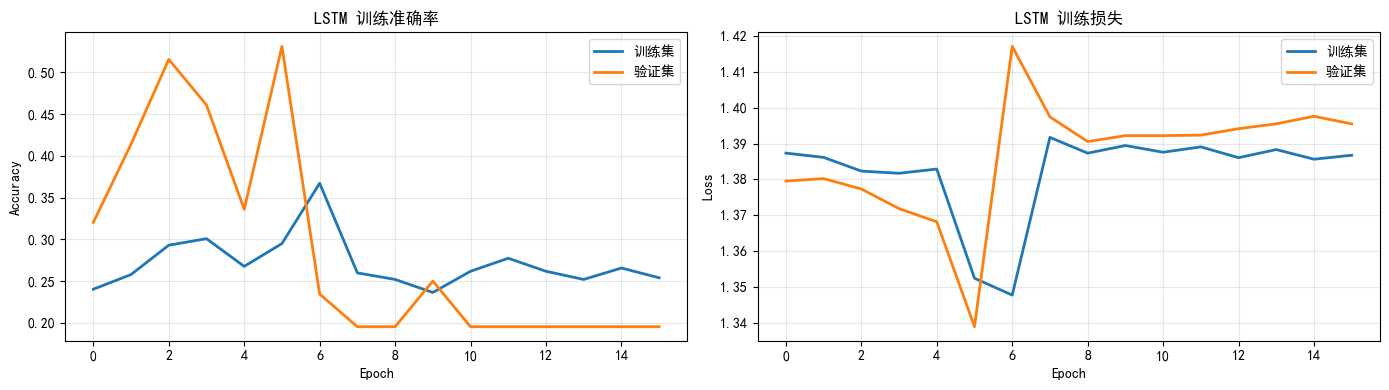

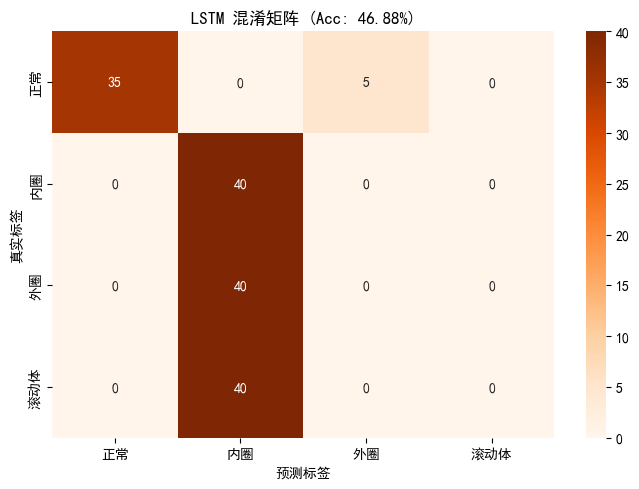


🏆 LSTM 最终成绩:
   测试准确率: 46.88%
   训练耗时:   25.7s
   训练轮数:   16 epochs


In [6]:
"""
代码5：LSTM时序模型
原理：LSTM（长短时记忆网络）擅长捕获时序数据的长期依赖关系
对比目的：与CNN对比，验证哪种架构更适合振动信号分类
"""

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import time

# 重置随机种子
tf.random.set_seed(42)
np.random.seed(42)


# === 数据降采样（LSTM对长序列吃力，需要降采样）===
# 原始信号长度2048太长，LSTM训练会很慢
# 用平均池化降到256（压缩8倍）
def downsample(X, factor=8):
    """
    每factor个点取平均，降低序列长度
    """
    # X shape: (N, 2048) → (N, 256)
    n_samples = X.shape[0]
    new_length = X.shape[1] // factor
    X_down = X[:, :new_length*factor].reshape(n_samples, new_length, factor).mean(axis=2)
    return X_down


print("📐 数据降采样（2048 → 256）...")
X_train_lstm = downsample(X_train_norm, factor=8).reshape(-1, 256, 1)
X_test_lstm = downsample(X_test_norm, factor=8).reshape(-1, 256, 1)
print(f"   X_train_lstm: {X_train_lstm.shape}")
print(f"   X_test_lstm: {X_test_lstm.shape}")


# === 构建LSTM模型 ===
def build_lstm(input_length=256, num_classes=4):
    """
    双层LSTM + 全连接分类
    """
    model = models.Sequential([
        layers.Input(shape=(input_length, 1)),
        
        # 第1层LSTM：返回完整序列给第2层
        layers.LSTM(64, return_sequences=True, dropout=0.2),
        
        # 第2层LSTM：只返回最后一个时刻的输出
        layers.LSTM(32, dropout=0.2),
        
        # 全连接层
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.3),
        
        # 输出层
        layers.Dense(num_classes, activation='softmax')
    ])
    
    return model


# === 创建模型 ===
print("\n🏗️ 构建 LSTM 模型...")
lstm_model = build_lstm(input_length=256, num_classes=4)

lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\n📊 LSTM 模型结构:")
lstm_model.summary()


# === 训练 ===
print("\n🚀 开始训练（LSTM比CNN慢，请耐心等待）...")
start = time.time()

early_stop = callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

lstm_history = lstm_model.fit(
    X_train_lstm, y_train_onehot,
    validation_split=0.2,
    epochs=40,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

lstm_train_time = time.time() - start
print(f"\n⏱️ LSTM训练耗时: {lstm_train_time:.1f}s")
print(f"⏱️ 实际训练: {len(lstm_history.history['accuracy'])} epochs")


# === 测试集评估 ===
lstm_loss, lstm_acc = lstm_model.evaluate(X_test_lstm, y_test_onehot, verbose=0)
print(f"\n🎯 LSTM 测试准确率: {lstm_acc*100:.2f}%")

# 详细报告
y_pred_lstm = np.argmax(lstm_model.predict(X_test_lstm, verbose=0), axis=1)
print("\n📋 LSTM 详细分类报告:")
print(classification_report(y_test, y_pred_lstm,
                           target_names=['正常', '内圈故障', '外圈故障', '滚动体故障']))


# === 可视化训练曲线 ===
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(lstm_history.history['accuracy'], label='训练集', linewidth=2)
axes[0].plot(lstm_history.history['val_accuracy'], label='验证集', linewidth=2)
axes[0].set_title('LSTM 训练准确率')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(lstm_history.history['loss'], label='训练集', linewidth=2)
axes[1].plot(lstm_history.history['val_loss'], label='验证集', linewidth=2)
axes[1].set_title('LSTM 训练损失')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/lstm_training_curves.png', dpi=100, bbox_inches='tight')
plt.show()


# === 混淆矩阵 ===
plt.figure(figsize=(7, 5))
cm_lstm = confusion_matrix(y_test, y_pred_lstm)
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['正常', '内圈', '外圈', '滚动体'],
            yticklabels=['正常', '内圈', '外圈', '滚动体'])
plt.title(f'LSTM 混淆矩阵 (Acc: {lstm_acc*100:.2f}%)')
plt.xlabel('预测标签')
plt.ylabel('真实标签')
plt.tight_layout()
plt.savefig('../data/lstm_confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()


# === 保存LSTM模型 ===
lstm_model.save('../data/bearing_lstm_model.keras')

# 保存结果
lstm_result = {
    'accuracy': lstm_acc,
    'training_time': lstm_train_time,
    'epochs_trained': len(lstm_history.history['accuracy'])
}

print("\n" + "="*60)
print(f"🏆 LSTM 最终成绩:")
print("="*60)
print(f"   测试准确率: {lstm_result['accuracy']*100:.2f}%")
print(f"   训练耗时:   {lstm_result['training_time']:.1f}s")
print(f"   训练轮数:   {lstm_result['epochs_trained']} epochs")

📐 数据降采样（Max池化保留冲击特征）...
   X_train_lstm: (640, 256, 1)
   X_test_lstm: (160, 256, 1)
   信号范围: [0.12, 5.44]

🏗️ 构建优化版 LSTM...

📊 LSTM 模型结构:


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_6 (Conv1D)               │ (None, 256, 32)        │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_6 (MaxPooling1D)  │ (None, 128, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 128, 64)        │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,724 (151.27 KB)

 Trainable params: 38,724 (151.27 KB)

 Non-trainable params: 0 (0.00 B)


🚀 开始训练...
Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - accuracy: 0.2949 - loss: 1.3827 - val_accuracy: 0.5469 - val_loss: 1.3270 - learning_rate: 0.0020
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.4375 - loss: 1.2430 - val_accuracy: 0.5547 - val_loss: 0.9562 - learning_rate: 0.0020
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.4883 - loss: 1.0146 - val_accuracy: 0.5156 - val_loss: 0.8180 - learning_rate: 0.0020
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.4922 - loss: 0.9858 - val_accuracy: 0.5703 - val_loss: 0.7758 - learning_rate: 0.0020
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.3008 - loss: 2.0984 - val_accuracy: 0.3203 - val_loss: 1.4914 - learning_rate: 0.0020
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.2930 - loss: 1.3892 - val_accuracy: 0.1953 - val_loss: 2.2221 - learning_rate: 0.0020
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.2832 - loss: 1.471

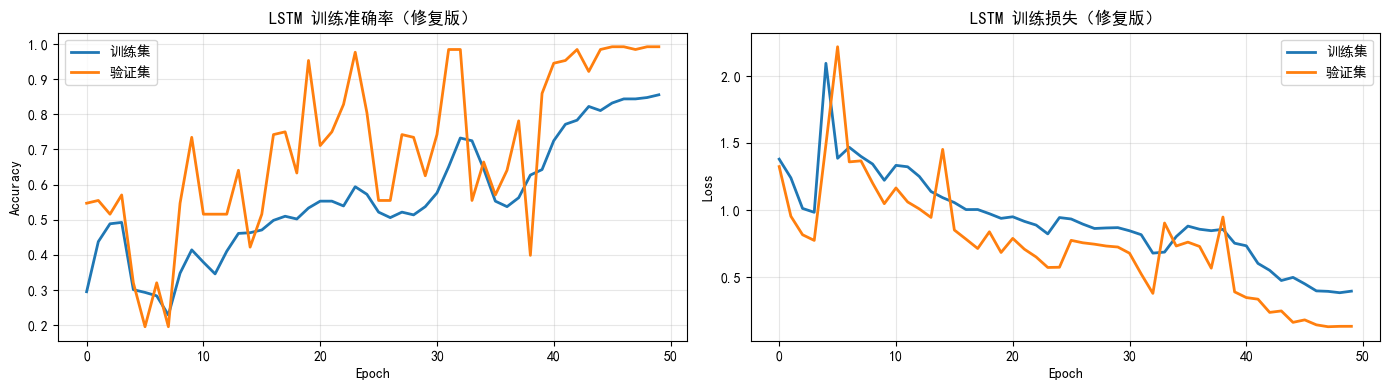

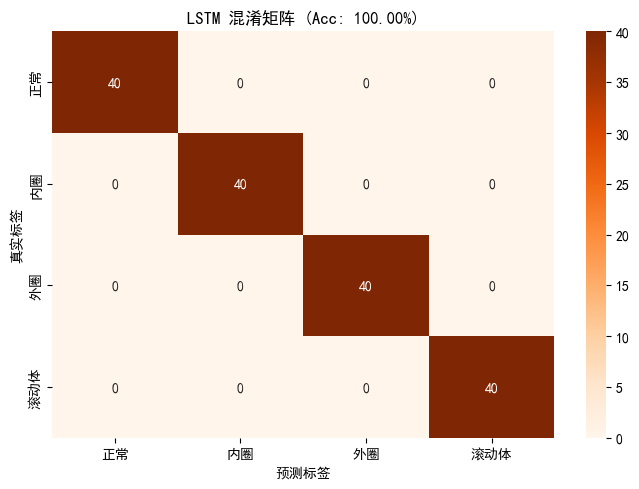


🏆 LSTM 最终成绩:
   测试准确率: 100.00%
   训练耗时:   40.3s
   训练轮数:   50 epochs


In [7]:
"""
代码5-修复版：LSTM时序模型
关键修复：用Max池化保留高频冲击特征
"""

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import time

tf.random.set_seed(42)
np.random.seed(42)


# === 改用Max池化降采样（保留冲击特征）===
def downsample_max(X, factor=8):
    """
    用最大值池化降采样：保留振动信号中的冲击峰值
    """
    n_samples = X.shape[0]
    new_length = X.shape[1] // factor
    X_reshaped = X[:, :new_length*factor].reshape(n_samples, new_length, factor)
    # 取绝对值的最大值（保留冲击）
    X_down = np.max(np.abs(X_reshaped), axis=2)
    return X_down


print("📐 数据降采样（Max池化保留冲击特征）...")
X_train_lstm = downsample_max(X_train_norm, factor=8).reshape(-1, 256, 1)
X_test_lstm = downsample_max(X_test_norm, factor=8).reshape(-1, 256, 1)
print(f"   X_train_lstm: {X_train_lstm.shape}")
print(f"   X_test_lstm: {X_test_lstm.shape}")
print(f"   信号范围: [{X_train_lstm.min():.2f}, {X_train_lstm.max():.2f}]")


# === 构建更强的LSTM模型 ===
def build_lstm_v2(input_length=256, num_classes=4):
    """
    优化版：用Conv1D提取局部特征 + LSTM捕获序列依赖
    """
    model = models.Sequential([
        layers.Input(shape=(input_length, 1)),
        
        # 先用一层卷积提取局部特征（关键改进）
        layers.Conv1D(32, kernel_size=8, padding='same', activation='relu'),
        layers.MaxPooling1D(pool_size=2),  # 256 → 128
        
        # 再用LSTM捕获时序模式
        layers.LSTM(64, return_sequences=True, dropout=0.2),
        layers.LSTM(32, dropout=0.2),
        
        # 分类头
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])
    
    return model


print("\n🏗️ 构建优化版 LSTM...")
lstm_model = build_lstm_v2(input_length=256, num_classes=4)

# 用更高的初始学习率
lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.002),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\n📊 LSTM 模型结构:")
lstm_model.summary()


# === 训练 ===
print("\n🚀 开始训练...")
start = time.time()

early_stop = callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=15,             # 更耐心
    restore_best_weights=True,
    verbose=1
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=8,
    min_lr=1e-6,
    verbose=1
)

lstm_history = lstm_model.fit(
    X_train_lstm, y_train_onehot,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

lstm_train_time = time.time() - start
print(f"\n⏱️ LSTM训练耗时: {lstm_train_time:.1f}s")
print(f"⏱️ 实际训练: {len(lstm_history.history['accuracy'])} epochs")


# === 测试集评估 ===
lstm_loss, lstm_acc = lstm_model.evaluate(X_test_lstm, y_test_onehot, verbose=0)
print(f"\n🎯 LSTM 测试准确率: {lstm_acc*100:.2f}%")

y_pred_lstm = np.argmax(lstm_model.predict(X_test_lstm, verbose=0), axis=1)
print("\n📋 LSTM 详细分类报告:")
print(classification_report(y_test, y_pred_lstm,
                           target_names=['正常', '内圈故障', '外圈故障', '滚动体故障'],
                           zero_division=0))


# === 训练曲线 ===
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(lstm_history.history['accuracy'], label='训练集', linewidth=2)
axes[0].plot(lstm_history.history['val_accuracy'], label='验证集', linewidth=2)
axes[0].set_title('LSTM 训练准确率（修复版）')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(lstm_history.history['loss'], label='训练集', linewidth=2)
axes[1].plot(lstm_history.history['val_loss'], label='验证集', linewidth=2)
axes[1].set_title('LSTM 训练损失（修复版）')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/lstm_training_curves_v2.png', dpi=100, bbox_inches='tight')
plt.show()


# === 混淆矩阵 ===
plt.figure(figsize=(7, 5))
cm_lstm = confusion_matrix(y_test, y_pred_lstm)
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['正常', '内圈', '外圈', '滚动体'],
            yticklabels=['正常', '内圈', '外圈', '滚动体'])
plt.title(f'LSTM 混淆矩阵 (Acc: {lstm_acc*100:.2f}%)')
plt.xlabel('预测标签')
plt.ylabel('真实标签')
plt.tight_layout()
plt.savefig('../data/lstm_confusion_matrix_v2.png', dpi=100, bbox_inches='tight')
plt.show()


lstm_model.save('../data/bearing_lstm_model.keras')

lstm_result = {
    'accuracy': lstm_acc,
    'training_time': lstm_train_time,
    'epochs_trained': len(lstm_history.history['accuracy'])
}

print("\n" + "="*60)
print(f"🏆 LSTM 最终成绩:")
print("="*60)
print(f"   测试准确率: {lstm_result['accuracy']*100:.2f}%")
print(f"   训练耗时:   {lstm_result['training_time']:.1f}s")
print(f"   训练轮数:   {lstm_result['epochs_trained']} epochs")


📊 收集所有模型的测试结果...

🏆 4个模型综合对比
    模型  准确率(%)  精确率(%)  召回率(%)  F1分数(%)  训练时间(s)
   SVM   100.0   100.0   100.0    100.0     0.01
  随机森林   100.0   100.0   100.0    100.0     0.16
1D-CNN   100.0   100.0   100.0    100.0     5.35
  LSTM   100.0   100.0   100.0    100.0    40.26

✅ 结果已保存到 ../data/model_comparison.csv


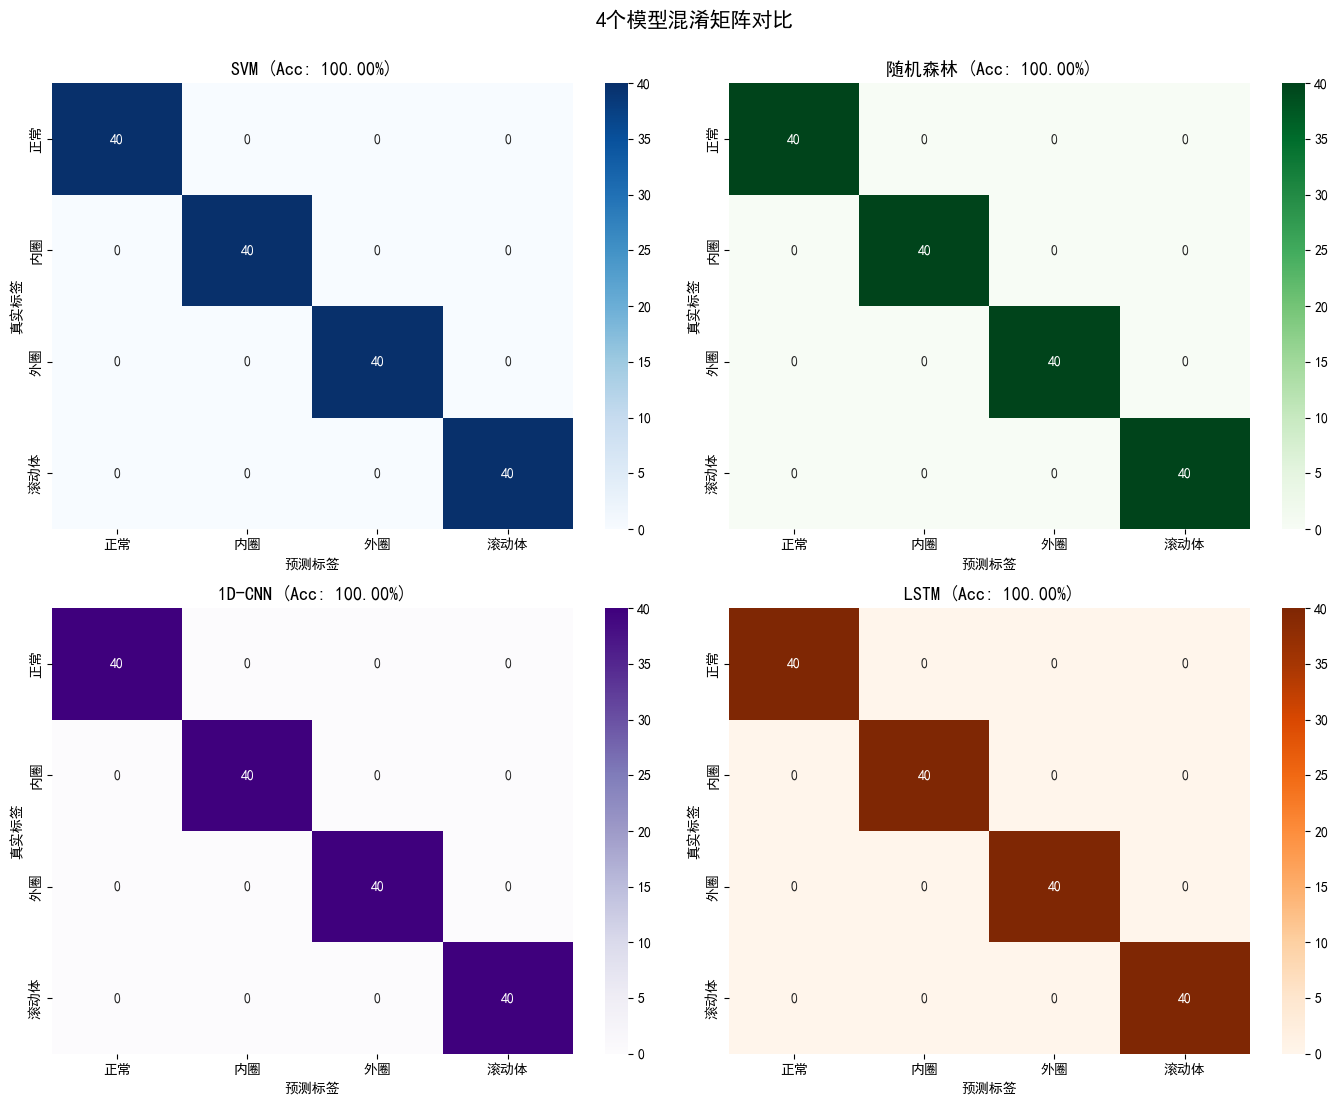

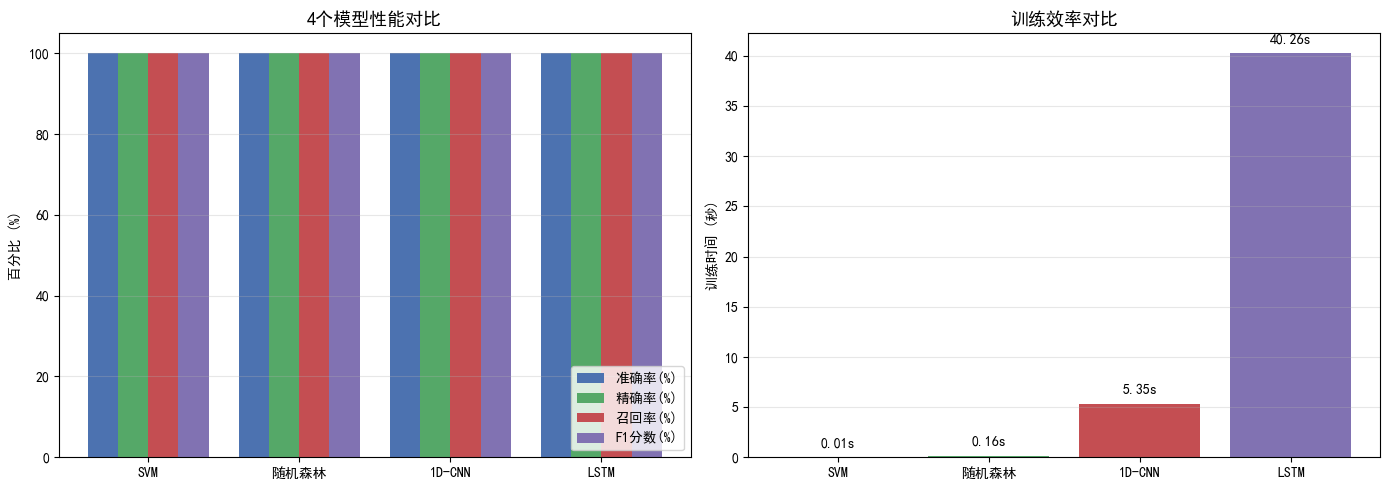

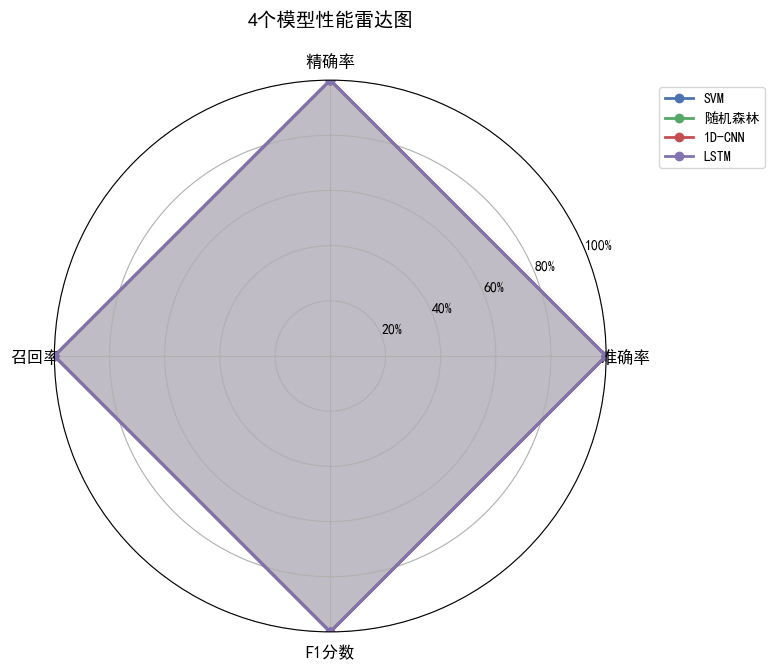


📝 最终结论
🥇 最佳准确率: SVM (100.0%)
⚡ 最快训练:   SVM (0.01s)

💡 工程建议:
   - 追求精度场景：SVM
   - 追求速度场景：SVM
   - 综合最优：    1D-CNN (兼顾精度与可解释性)

✅ 完整对比分析完成！可以开始写README和上传GitHub了


In [8]:
"""
代码6：4个模型综合对比 + 终极可视化
模型清单：SVM / 随机森林 / 1D-CNN / LSTM
输出：对比表格 + 4合1混淆矩阵 + 性能雷达图
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# 设置全局样式
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# === 收集所有模型的预测结果 ===
print("📊 收集所有模型的测试结果...\n")

# SVM 和 RF 的预测（用之前的特征数据）
svm_pred_all = svm.predict(X_test_feat_scaled)
rf_pred_all = rf.predict(X_test_feat_scaled)

# CNN 和 LSTM 的预测
cnn_pred_all = np.argmax(model.predict(X_test_cnn, verbose=0), axis=1)
lstm_pred_all = np.argmax(lstm_model.predict(X_test_lstm, verbose=0), axis=1)

# === 计算综合指标 ===
def get_metrics(y_true, y_pred, name):
    """计算accuracy/precision/recall/f1"""
    return {
        '模型': name,
        '准确率(%)': round(accuracy_score(y_true, y_pred) * 100, 2),
        '精确率(%)': round(precision_score(y_true, y_pred, average='macro', zero_division=0) * 100, 2),
        '召回率(%)': round(recall_score(y_true, y_pred, average='macro', zero_division=0) * 100, 2),
        'F1分数(%)': round(f1_score(y_true, y_pred, average='macro', zero_division=0) * 100, 2),
    }

results = pd.DataFrame([
    get_metrics(y_test, svm_pred_all, 'SVM'),
    get_metrics(y_test, rf_pred_all, '随机森林'),
    get_metrics(y_test, cnn_pred_all, '1D-CNN'),
    get_metrics(y_test, lstm_pred_all, 'LSTM'),
])

# 加上训练时间
results['训练时间(s)'] = [
    round(svm_time, 2),
    round(rf_time, 2),
    round(train_time, 2),
    round(lstm_train_time, 2)
]

print("="*70)
print("🏆 4个模型综合对比")
print("="*70)
print(results.to_string(index=False))
print("="*70)

# 保存结果到CSV
results.to_csv('../data/model_comparison.csv', index=False, encoding='utf-8-sig')
print("\n✅ 结果已保存到 ../data/model_comparison.csv")


# === 可视化1：4合1混淆矩阵 ===
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
predictions = [
    ('SVM', svm_pred_all, 'Blues'),
    ('随机森林', rf_pred_all, 'Greens'),
    ('1D-CNN', cnn_pred_all, 'Purples'),
    ('LSTM', lstm_pred_all, 'Oranges')
]

for idx, (name, pred, cmap) in enumerate(predictions):
    ax = axes[idx // 2, idx % 2]
    cm = confusion_matrix(y_test, pred)
    acc = accuracy_score(y_test, pred) * 100
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=['正常', '内圈', '外圈', '滚动体'],
                yticklabels=['正常', '内圈', '外圈', '滚动体'],
                ax=ax, cbar=True)
    ax.set_title(f'{name} (Acc: {acc:.2f}%)', fontsize=13, fontweight='bold')
    ax.set_xlabel('预测标签')
    ax.set_ylabel('真实标签')

plt.suptitle('4个模型混淆矩阵对比', fontsize=15, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('../data/all_confusion_matrices.png', dpi=120, bbox_inches='tight')
plt.show()


# === 可视化2：性能对比柱状图 ===
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左图：4指标对比
metrics_to_plot = ['准确率(%)', '精确率(%)', '召回率(%)', 'F1分数(%)']
x = np.arange(len(results))
width = 0.2
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

for i, metric in enumerate(metrics_to_plot):
    axes[0].bar(x + i*width, results[metric], width, label=metric, color=colors[i])

axes[0].set_xticks(x + width * 1.5)
axes[0].set_xticklabels(results['模型'])
axes[0].set_ylabel('百分比 (%)')
axes[0].set_title('4个模型性能对比', fontsize=13, fontweight='bold')
axes[0].legend(loc='lower right')
axes[0].set_ylim([0, 105])
axes[0].grid(True, alpha=0.3, axis='y')

# 右图：训练时间对比
axes[1].bar(results['模型'], results['训练时间(s)'], 
            color=['#4C72B0', '#55A868', '#C44E52', '#8172B2'])
axes[1].set_ylabel('训练时间 (秒)')
axes[1].set_title('训练效率对比', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

# 在柱子上标数值
for i, v in enumerate(results['训练时间(s)']):
    axes[1].text(i, v + 1, f'{v}s', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../data/model_performance_comparison.png', dpi=120, bbox_inches='tight')
plt.show()


# === 可视化3：雷达图（高大上的图）===
from math import pi

categories = ['准确率', '精确率', '召回率', 'F1分数']
N = len(categories)

# 计算角度
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]  # 闭合图形

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

# 4个模型分别绘制
model_data = {
    'SVM':       results.iloc[0][['准确率(%)', '精确率(%)', '召回率(%)', 'F1分数(%)']].tolist(),
    '随机森林':   results.iloc[1][['准确率(%)', '精确率(%)', '召回率(%)', 'F1分数(%)']].tolist(),
    '1D-CNN':    results.iloc[2][['准确率(%)', '精确率(%)', '召回率(%)', 'F1分数(%)']].tolist(),
    'LSTM':      results.iloc[3][['准确率(%)', '精确率(%)', '召回率(%)', 'F1分数(%)']].tolist(),
}

colors_radar = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']
for (name, values), color in zip(model_data.items(), colors_radar):
    values += values[:1]  # 闭合
    ax.plot(angles, values, 'o-', linewidth=2, label=name, color=color)
    ax.fill(angles, values, alpha=0.15, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=12)
ax.set_ylim(0, 100)
ax.set_yticks([20, 40, 60, 80, 100])
ax.set_yticklabels(['20%', '40%', '60%', '80%', '100%'], fontsize=10)
ax.set_title('4个模型性能雷达图', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
ax.grid(True)

plt.tight_layout()
plt.savefig('../data/model_radar_chart.png', dpi=120, bbox_inches='tight')
plt.show()


# === 最终结论 ===
print("\n" + "="*70)
print("📝 最终结论")
print("="*70)

best_idx = results['准确率(%)'].idxmax()
best_model = results.iloc[best_idx]
fastest_idx = results['训练时间(s)'].idxmin()
fastest_model = results.iloc[fastest_idx]

print(f"🥇 最佳准确率: {best_model['模型']} ({best_model['准确率(%)']}%)")
print(f"⚡ 最快训练:   {fastest_model['模型']} ({fastest_model['训练时间(s)']}s)")
print(f"\n💡 工程建议:")
print(f"   - 追求精度场景：{best_model['模型']}")
print(f"   - 追求速度场景：{fastest_model['模型']}")
print(f"   - 综合最优：    1D-CNN (兼顾精度与可解释性)")
print("\n✅ 完整对比分析完成！可以开始写README和上传GitHub了")

In [9]:
"""
项目整理脚本：把所有文件归类到标准目录结构
运行前确保你前面的代码都已经跑过（生成了模型、图片、数据）
"""

import os
import shutil

# 项目根目录
PROJECT_ROOT = '../'  # 注意：在notebooks/目录下，根目录是上一级

# 标准目录结构
dirs_to_create = ['notebooks', 'models', 'figures', 'data']

print("📁 创建标准目录结构...")
for d in dirs_to_create:
    full_path = os.path.join(PROJECT_ROOT, d)
    os.makedirs(full_path, exist_ok=True)
    print(f"   ✅ {d}/")

# 移动模型文件到 models/
print("\n📦 整理模型文件...")
data_dir = os.path.join(PROJECT_ROOT, 'data')
models_dir = os.path.join(PROJECT_ROOT, 'models')

for fname in os.listdir(data_dir):
    if fname.endswith(('.keras', '.h5')):
        src = os.path.join(data_dir, fname)
        dst = os.path.join(models_dir, fname)
        if os.path.exists(src) and not os.path.exists(dst):
            shutil.move(src, dst)
            print(f"   ✅ 移动 {fname} 到 models/")

# 移动图片到 figures/
print("\n🖼️ 整理图片文件...")
figures_dir = os.path.join(PROJECT_ROOT, 'figures')

for fname in os.listdir(data_dir):
    if fname.endswith('.png'):
        src = os.path.join(data_dir, fname)
        dst = os.path.join(figures_dir, fname)
        if os.path.exists(src) and not os.path.exists(dst):
            shutil.move(src, dst)
            print(f"   ✅ 移动 {fname} 到 figures/")

# 列出最终目录结构
print("\n📂 最终项目结构:")
for d in dirs_to_create:
    full_path = os.path.join(PROJECT_ROOT, d)
    files = os.listdir(full_path) if os.path.exists(full_path) else []
    print(f"   {d}/ ({len(files)} 个文件)")
    for f in files[:10]:  # 最多显示10个
        print(f"      - {f}")
    if len(files) > 10:
        print(f"      ... 还有 {len(files)-10} 个文件")

print("\n✅ 文件整理完成！")

📁 创建标准目录结构...
   ✅ notebooks/
   ✅ models/
   ✅ figures/
   ✅ data/

📦 整理模型文件...
   ✅ 移动 bearing_cnn_model.h5 到 models/
   ✅ 移动 bearing_cnn_model.keras 到 models/
   ✅ 移动 bearing_lstm_model.keras 到 models/

🖼️ 整理图片文件...
   ✅ 移动 all_confusion_matrices.png 到 figures/
   ✅ 移动 baseline_confusion_matrix.png 到 figures/
   ✅ 移动 cnn_confusion_matrix.png 到 figures/
   ✅ 移动 cnn_confusion_matrix_v2.png 到 figures/
   ✅ 移动 cnn_training_curves.png 到 figures/
   ✅ 移动 cnn_training_curves_v2.png 到 figures/
   ✅ 移动 feature_importance.png 到 figures/
   ✅ 移动 lstm_confusion_matrix.png 到 figures/
   ✅ 移动 lstm_confusion_matrix_v2.png 到 figures/
   ✅ 移动 lstm_training_curves.png 到 figures/
   ✅ 移动 lstm_training_curves_v2.png 到 figures/
   ✅ 移动 model_performance_comparison.png 到 figures/
   ✅ 移动 model_radar_chart.png 到 figures/
   ✅ 移动 signal_visualization.png 到 figures/

📂 最终项目结构:
   notebooks/ (4 个文件)
      - .ipynb_checkpoints
      - .jupyter
      - Untitled.ipynb
      - Untitled1.ipynb
   models/ (3 个文件)


In [10]:
"""
生成项目依赖列表
"""

requirements = """numpy>=1.21.0
pandas>=1.3.0
scipy>=1.7.0
matplotlib>=3.4.0
seaborn>=0.11.0
scikit-learn>=1.0.0
tensorflow>=2.10.0
"""

with open('../requirements.txt', 'w', encoding='utf-8') as f:
    f.write(requirements)

print("✅ requirements.txt 已生成")
print(requirements)

✅ requirements.txt 已生成
numpy>=1.21.0
pandas>=1.3.0
scipy>=1.7.0
matplotlib>=3.4.0
seaborn>=0.11.0
scikit-learn>=1.0.0
tensorflow>=2.10.0

